# Practica 2 - Ejercicio 3) Simulación estocástica.

Consideramos un sistema con reproducción y competencia intrasepecífica del tipo:

$$
\begin{align*}
& A \rightarrow A + A & \quad \text{con tasa } b \\
& A + A \rightarrow A & \quad \text{con tasa } d \\
\end{align*}
$$

Vamos a simular el sistema utilizando el algoritmo de Gillespie.

In [2]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.ticker import AutoMinorLocator

In [3]:
def solucion_logistica(t, A0, b, d):
    K = b/d
    r = b
    return (A0 * K * np.exp(r * t) ) / (K + A0 * (np.exp(r * t) - 1))

In [4]:
def solucion_guillespie(tf, A0, b, d):
    # Inicializamos la población
    A = [A0]
    t_list = [0]
    tau = 0
    t = 0

    # Iteramos hasta que el tiempo final sea alcanzado
    while tau + t_list[-1] <= tf:
        # Chequeamos si la población se extinguió
        if A[t] == 0:
            break
        
        # Cacluamos la probabilidad de que ocurra un nacimiento
        h_b = A[t] # Número de combinaciones para que ocurra un nacimiento
        a_b = h_b * b

        # Calculamos la probabilidad de que ocurra una muerte
        h_d = A[t]*A[t] # Número de combinaciones para que ocurra una muerte por competencia
        a_d = h_d * d

        # Tenemos que generar P(tau, i), donde i es b o d
        # Necesitamos primero la probabilidad de que NO ocurra NINGUN nacimiento ni muerte entre t y t + tau
        a_0 =  a_b + a_d

        # El tiempo de espera para que ocurra un evento es una variable aleatoria exponencial con exponente a_0
        # Para generar un tiempo de espera, necesitamos un número aleatorio entre 0 y 1
        # Usamos el método de la inversa de la función de distribución acumulada
        w_1 = np.random.rand()
        tau = np.log(1/w_1)/a_0

        # Para identificar si lo que ocurrió fue un nacimiento o una muerte lo hacemos
        # con otro número aleatorio entre 0 y a_0. La reacción será un nacimiento si el número
        # aleatorio es menor que a_b. En caso contrario, será una muerte

        w_2 = a_0 * np.random.rand()
        if w_2 < a_b:
            last = A[t]
            A.append(last + 1)
            t+=1
        else:
            last = A[t]
            A.append(last - 1)
            t+=1
            
        last_t = t_list[-1]
        t_list.append(tau + last_t)

    return t_list, A

Analicemos algunos de los casos característicos recordando que el modelo macroscópico para este modelo es la ecuación logística 

$$\begin{equation}
    \frac{dA}{dt} = bA\left(1-\frac{A}{b/d}\right)
\end{equation}$$

donde $b/d$ es la capacidad de carga del sistema y $b$ es la tasa de crecimiento de la población.

1. Para $A_0$ pequeño por debajo de $\frac{b/d}{2}$ la población crece como una curva concava
2. Para $A_0$ grande por encima de $\frac{b/d}{2}$ y menor a $b/d$ la población crece como una curva convexa
3. Para $A_0$ mayor a $b/d$ la población decrece hasta llegar a la capacidad de carga del sistema

Supongamos que $b = 1$, $d = 0.01$, entonces la capacidad de carga del sistema es $b/d = 100$.
tomemos $A_0 = 10$, $A_0 = 50$ y $A_0 = 150$ veamos como se comporta la población en cada caso.

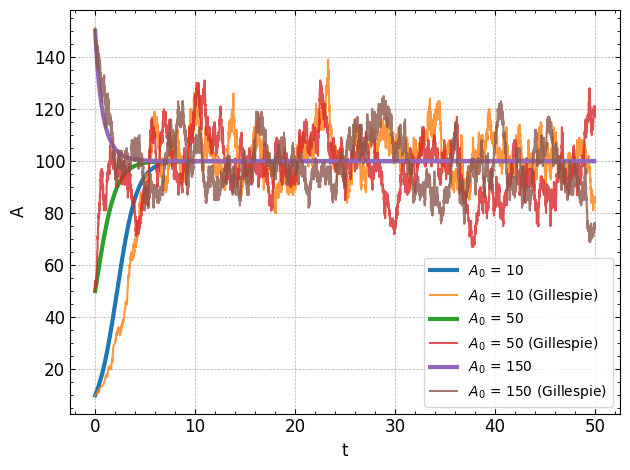

In [8]:
A0s = [10, 50, 150]
b = 1
d = 0.01
tf = 50
t = np.arange(0, tf, 0.1)
for A0 in A0s:
    time, A = solucion_guillespie(tf, A0, b, d)
    plt.plot(t, solucion_logistica(t, A0, b, d), label=f"$A_0$ = {A0}", lw = 3)
    plt.plot(time, A, label=f"$A_0$ = {A0} (Gillespie)", alpha = 0.8)
plt.xlabel("t", fontsize = 12)
plt.ylabel("A", fontsize = 12)
plt.gca().xaxis.set_major_locator(plt.AutoLocator())
plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_major_locator(plt.AutoLocator())
plt.gca().yaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_ticks_position('both')
plt.gca().xaxis.set_ticks_position('both')
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=12)
plt.grid(linestyle='--', linewidth=0.5)
plt.legend(loc = 'best')
plt.tight_layout()
plt.savefig("EstacionarioComparacion.pdf")
plt.show()

Ahora grafiquemos la població utilizando distintos valores de $b$ y $d$.

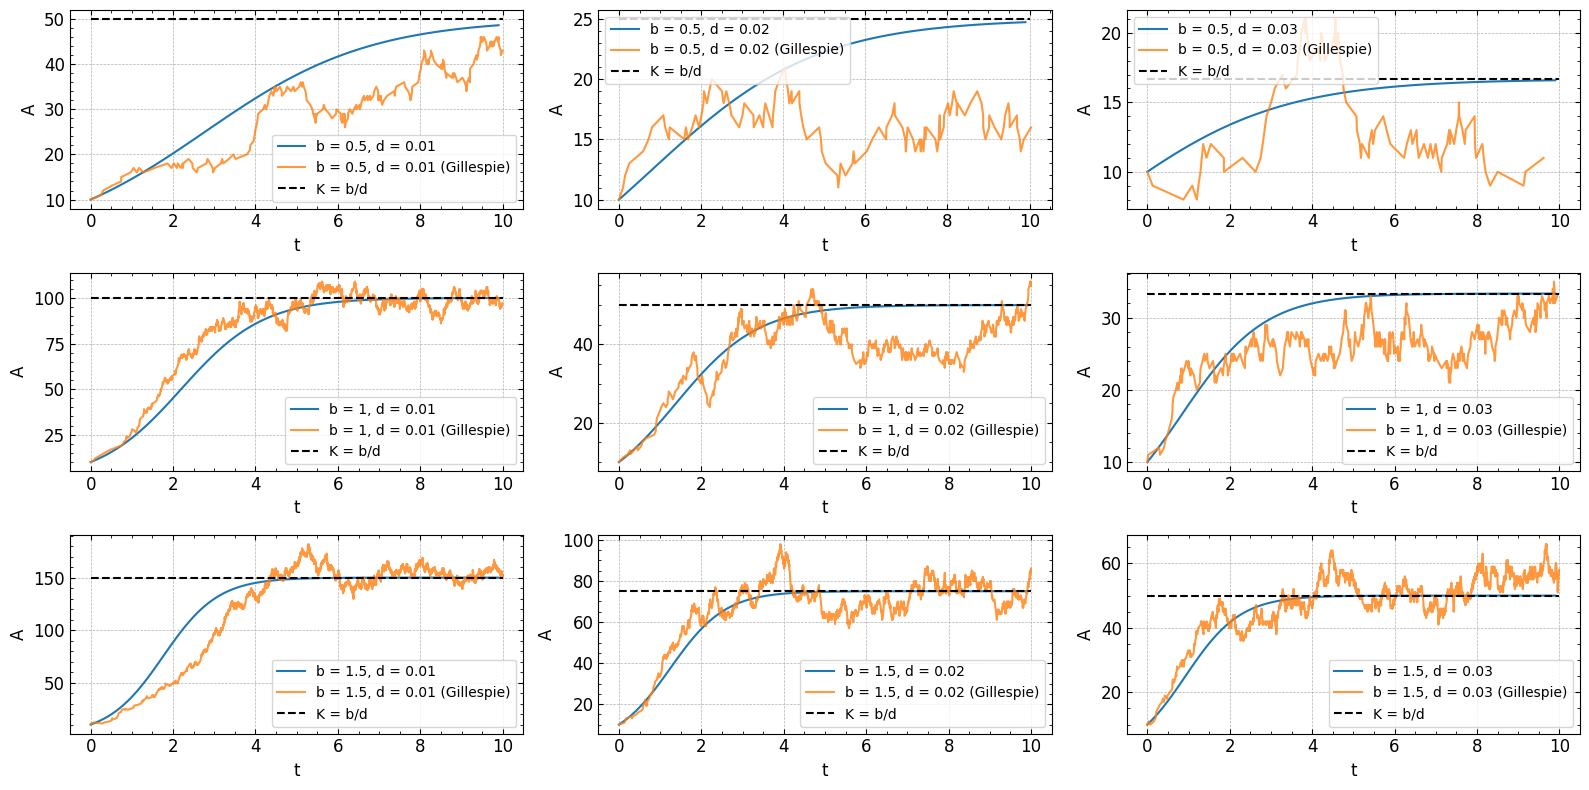

In [9]:
bs = [0.5, 1, 1.5]
ds = [0.01, 0.02, 0.03]
A0 = 10
tf = 10
t = np.arange(0, tf, 0.1)

fig, ax = plt.subplots(3, 3, figsize = (16, 8))

for i, b in enumerate(bs):
    for j, d in enumerate(ds):
        time, A = solucion_guillespie(tf, A0, b, d)
        ax[i, j].plot(t, solucion_logistica(t, A0, b, d), label=f"b = {b}, d = {d}")
        ax[i, j].plot(time, A, label=f"b = {b}, d = {d} (Gillespie)", alpha = 0.8)
        ax[i, j].hlines(b/d, 0, tf, linestyle = "--", color = "black", label = "K = b/d")
        ax[i, j].set_xlabel("t", fontsize = 12)
        ax[i, j].set_ylabel("A", fontsize = 12)
        ax[i, j].xaxis.set_major_locator(plt.AutoLocator())
        ax[i, j].xaxis.set_minor_locator(AutoMinorLocator())
        ax[i, j].yaxis.set_major_locator(plt.AutoLocator())
        ax[i, j].yaxis.set_minor_locator(AutoMinorLocator())
        ax[i, j].yaxis.set_ticks_position('both')
        ax[i, j].xaxis.set_ticks_position('both')
        ax[i, j].tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=12)
        ax[i, j].grid(linestyle='--', linewidth=0.5)
        ax[i, j].legend(loc = 'best')
plt.tight_layout()
plt.savefig("Comparacion2.pdf")
plt.show()

    #     plt.plot(t, solucion_logistica(t, A0, b, d), label=f"b = {b}, d = {d}")
    #     plt.plot(time, A, label=f"b = {b}, d = {d} (Gillespie)", alpha = 0.8)
    # plt.xlabel("t", fontsize = 12)
    # plt.ylabel("A", fontsize = 12)
    # plt.gca().xaxis.set_major_locator(plt.AutoLocator())
    # plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
    # plt.gca().yaxis.set_major_locator(plt.AutoLocator())
    # plt.gca().yaxis.set_minor_locator(AutoMinorLocator())
    # plt.gca().yaxis.set_ticks_position('both')
    # plt.gca().xaxis.set_ticks_position('both')
    # plt.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=12)
    # plt.grid(linestyle='--', linewidth=0.5)
    # plt.legend(loc = 'best')
    # plt.tight_layout()
    # plt.savefig("EstacionarioComparacion2.pdf")
    # plt.show()


Vemos que para distintas tasas de crecimiento y muerte la población estocástica sigue aún de manera aproximada la ecuación logística antes mencionada

Elijamos ahora un $b$ y $d$ que nos permita tener un estado estacionario positivo, por ejemplo $b = 0.1$ y $d = 0.001$, usemos multiples realizaciones para calcular la distribución estacionaria de la población.

Realización 0 de 1000


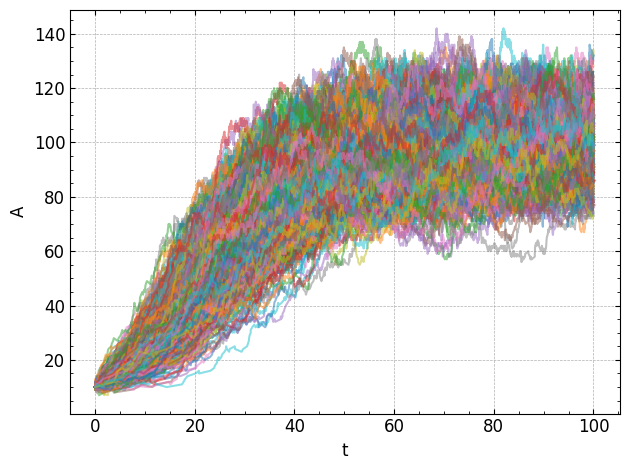

In [22]:
# Seteamos los parámetros
b = 0.1
d = 0.001
tf = 100
# Seteamos el número de realizaciones
N_realiz = 1000
# Vamos a guardar el último valor de A para cada realización
A_final = np.zeros(N_realiz)

# Iteramos sobre el número de realizaciones
for i in range(N_realiz):
    time, A = solucion_guillespie(tf, A0, b, d)
    A_final[i] = A[-1]
    if i % 25000 == 0:
        print(f"Realización {i} de {N_realiz}")
    plt.plot(time, A, alpha = 0.5)
plt.xlabel("t", fontsize = 12)
plt.ylabel("A", fontsize = 12)
plt.gca().xaxis.set_major_locator(plt.AutoLocator())
plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_major_locator(plt.AutoLocator())
plt.gca().yaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_ticks_position('both')
plt.gca().xaxis.set_ticks_position('both')
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=12)
plt.grid(linestyle='--', linewidth=0.5)
plt.tight_layout()
# Quedan graficadas únicamente 25, para hacer la estadística uso 50000 realizaciones
plt.savefig("EstacionarioPositivoRealizaciones.pdf")
plt.show()

In [23]:
import seaborn as sns

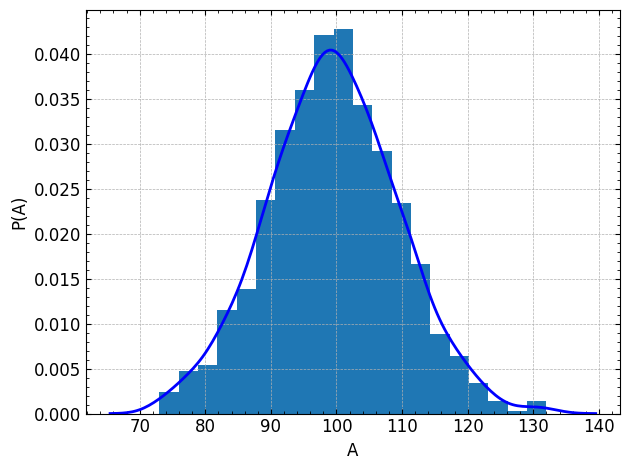

In [24]:
plt.hist(A_final, bins = 20, density = True, alpha = 1)
sns.kdeplot(A_final, color = 'b', linewidth = 2)
plt.xlabel("A", fontsize = 12)
plt.ylabel("P(A)", fontsize = 12)
plt.gca().xaxis.set_major_locator(plt.AutoLocator())
plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_major_locator(plt.AutoLocator())
plt.gca().yaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_ticks_position('both')
plt.gca().xaxis.set_ticks_position('both')
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=12)
plt.grid(linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig("EstacionarioPositivoHistograma.pdf")
plt.show()

Parecería tener una distribución gaussiana, calculemos la media y la varianza de la población en estado estacionario.

In [25]:
print(f"Media: {np.mean(A_final)}")
print(f"Desviación estándar: {np.std(A_final)}")

Media: 99.431
Desviación estándar: 9.975131026708372


In [26]:
# print(f"Media teórica: {b/d}")
# print(f"Desviación estándar teórica: {np.sqrt(b/d)}")

Ahora hagamos lo mismo para una elección de $b$ y $d$ que nos permita tener un estado estacionario nulo, por ejemplo $b = 0.1$ y $d = 0.2$, $A_0 = 10$ calculemos la media y la varianza de la población en estado estacionario.

In [27]:
b = 0.1
d = 0.2
A0 = 10
tf = 100

# Seteamos el número de realizaciones
N_realiz = 50000
# Vamos a guardar los tiempos de cada realización
t_final = np.zeros(N_realiz)

# Iteramos sobre el número de realizaciones
for i in range(N_realiz):
    time, A = solucion_guillespie(tf, A0, b, d)
    t_final[i] = time[-1]
    if i % 25000 == 0:
        print(f"Realización {i} de {N_realiz}")

Realización 0 de 50000
Realización 25000 de 50000


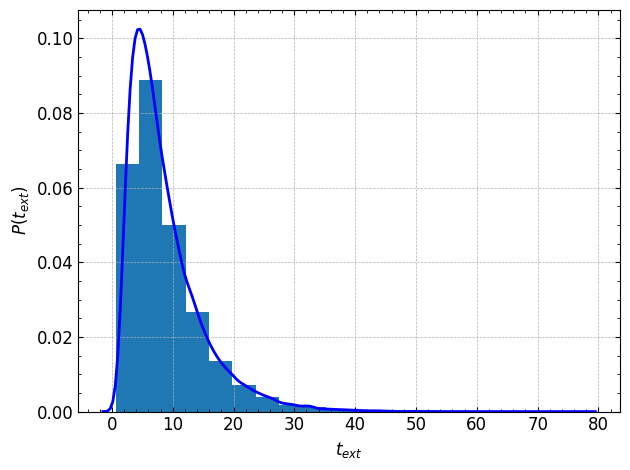

In [28]:
plt.hist(t_final, bins = 20, density = True, alpha = 1)
sns.kdeplot(t_final, color = 'b', linewidth = 2)
plt.xlabel(r"$t_{ext}$", fontsize = 12)
plt.ylabel(r"$P(t_{ext})$", fontsize = 12)
plt.gca().xaxis.set_major_locator(plt.AutoLocator())
plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_major_locator(plt.AutoLocator())
plt.gca().yaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_ticks_position('both')
plt.gca().xaxis.set_ticks_position('both')
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=12)
plt.grid(linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig("EstacionarioNegativoHistograma.pdf")
plt.show()

Parece una ditribución de Poisson, calculemos la media y la varianza de la población en estado estacionario.

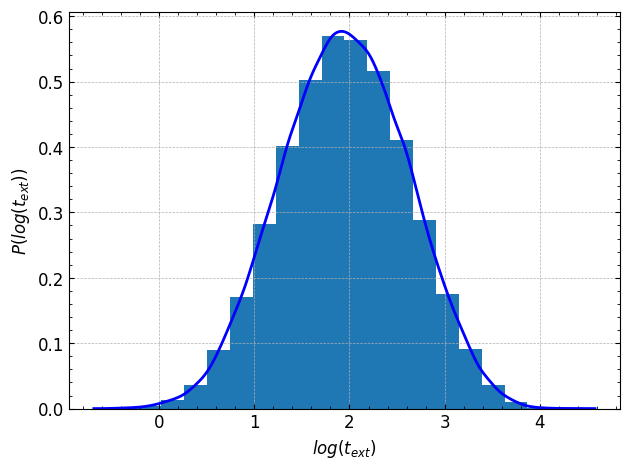

In [30]:
plt.hist(np.log(t_final), bins = 20, density = True, alpha = 1)
sns.kdeplot(np.log(t_final), color = 'b', linewidth = 2)
plt.xlabel(r"$log(t_{ext})$", fontsize = 12)
plt.ylabel(r"$P(log(t_{ext}))$", fontsize = 12)
plt.gca().xaxis.set_major_locator(plt.AutoLocator())
plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_major_locator(plt.AutoLocator())
plt.gca().yaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_ticks_position('both')
plt.gca().xaxis.set_ticks_position('both')
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=12)
plt.grid(linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig("EstacionarioNegativoLogHistograma.pdf")
plt.show()

In [12]:
print(f"Media: {np.mean(t_final)}")
print(f"Desviación estándar: {np.std(t_final)}")

Media: 8.647329195208444
Desviación estándar: 6.061317786483838
